# Data Loading

In [ ]:
!wget https://iasl-btm.iis.sinica.edu.tw/BNER/Content/Revised_JNLPBA.zip

--2025-10-15 22:29:03--  https://iasl-btm.iis.sinica.edu.tw/BNER/Content/Revised_JNLPBA.zip
Resolving iasl-btm.iis.sinica.edu.tw (iasl-btm.iis.sinica.edu.tw)... 140.109.20.133
Connecting to iasl-btm.iis.sinica.edu.tw (iasl-btm.iis.sinica.edu.tw)|140.109.20.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2533317 (2.4M) [application/x-zip-compressed]
Saving to: ‘Revised_JNLPBA.zip’

Revised_JNLPBA.zip  100%[===================>]   2.42M  1.44MB/s    in 1.7s    

2025-10-15 22:29:08 (1.44 MB/s) - ‘Revised_JNLPBA.zip’ saved [2533317/2533317]



In [ ]:
!unzip Revised_JNLPBA.zip -d Revised_JNLPBA

Archive:  Revised_JNLPBA.zip
  inflating: Revised_JNLPBA/Genia4EReval1.iob2  
  inflating: Revised_JNLPBA/Genia4EReval2.iob2  
  inflating: Revised_JNLPBA/Genia4ERtask1.iob2  
  inflating: Revised_JNLPBA/Genia4ERtask2.iob2  


In [ ]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=5abd7c045bf69a8c073f849de01d3d5f309215b9634f68b858c40aa0d2a9580f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import os
import re
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoModel
from sklearn.utils.class_weight import compute_class_weight

from seqeval.metrics import f1_score, classification_report

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BioBERT_Base1_PATH = "BioBERT_RAW/"
BioBERT_Weighted_PATH = "biobert_weighted.pt"

In [ ]:
def read_iob(file_path):
    sentences, labels = [], []
    tokens, tags = [], []
    header_pattern = re.compile(r"^###MEDLINE:\d+")

    with open(file_path, "r") as f:
      for line in f:
        line = line.strip()
        if not line:  # new sentence
          if tokens:
            sentences.append(tokens)
            labels.append(tags)
            tokens, tags = [], []
          continue


        if header_pattern.match(line):
          continue

        parts = line.split()
        if len(parts) == 2:
          word, tag = parts
          tokens.append(word)
          tags.append(tag)

      # last sentence
      if tokens:
        sentences.append(tokens)
        labels.append(tags)

    return sentences, labels


train_sent1, train_labels1 = read_iob("Revised_JNLPBA/Genia4ERtask1.iob2")
train_sent2, train_labels2 = read_iob("Revised_JNLPBA/Genia4ERtask2.iob2")
eval_sent1, eval_labels1   = read_iob("Revised_JNLPBA/Genia4EReval1.iob2")
eval_sent2, eval_labels2   = read_iob("Revised_JNLPBA/Genia4EReval2.iob2")

train_sentences = train_sent1 + train_sent2
train_labels    = train_labels1 + train_labels2

test_sentences  = eval_sent1 + eval_sent2
test_labels     = eval_labels1 + eval_labels2

unique_labels = sorted({lbl for seq in (test_labels) for lbl in seq})
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(unique_labels)

print("Labels:", unique_labels)

Labels: ['B-DNA', 'B-RNA', 'B-cell_line', 'B-cell_type', 'B-protein', 'I-DNA', 'I-RNA', 'I-cell_line', 'I-cell_type', 'I-protein', 'O']


In [ ]:
class NERDataset(Dataset):
  def __init__(self, sentences, labels, tokenizer, label2id, max_len=256):
    self.sentences = sentences
    self.labels = labels
    self.tokenizer = tokenizer
    self.label2id = label2id
    self.max_len = max_len

  def __len__(self):
    return len(self.sentences)

  def __getitem__(self, idx):
    # Tokenization
    tokens = self.sentences[idx]
    labels = self.labels[idx]

    encoding = self.tokenizer(
      tokens,
      is_split_into_words=True,
      truncation=True,
      padding='max_length',
      max_length=self.max_len,
      return_tensors='pt'
    )

    # Label Aligning for bert
    word_ids = encoding.word_ids(batch_index=0)

    label_ids = []
    for w_id in word_ids:
      if w_id is None:
        label_ids.append(-100)
      else:
        label_ids.append(self.label2id[labels[w_id]])

    label_ids = label_ids[:self.max_len] + [-100] * (self.max_len - len(label_ids))
    item = {key: val.squeeze(0) for key, val in encoding.items()}
    item["labels"] = torch.tensor(label_ids)
    return item

# BioBERT Base-1 Confusion Matrix

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BioBERT_Base1_PATH)
model = AutoModelForTokenClassification.from_pretrained(BioBERT_Base1_PATH).to(device)

test_dataset = NERDataset(test_sentences, test_labels, tokenizer, label2id)
test_loader = DataLoader(test_dataset, batch_size=32)

batch = next(iter(test_loader))
print(batch['input_ids'].shape)
print(batch['labels'].shape)

torch.Size([32, 256])
torch.Size([32, 256])


In [ ]:
model.eval()
true_labels, pred_labels = [], []

with torch.inference_mode():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=2)

        for i in range(len(labels)):
            true_seq, pred_seq = [], []
            for j in range(len(labels[i])):
                if labels[i][j] == -100:
                    continue
                true_seq.append(id2label[labels[i][j].item()])
                pred_seq.append(id2label[predictions[i][j].item()])
            true_labels.append(true_seq)
            pred_labels.append(pred_seq)


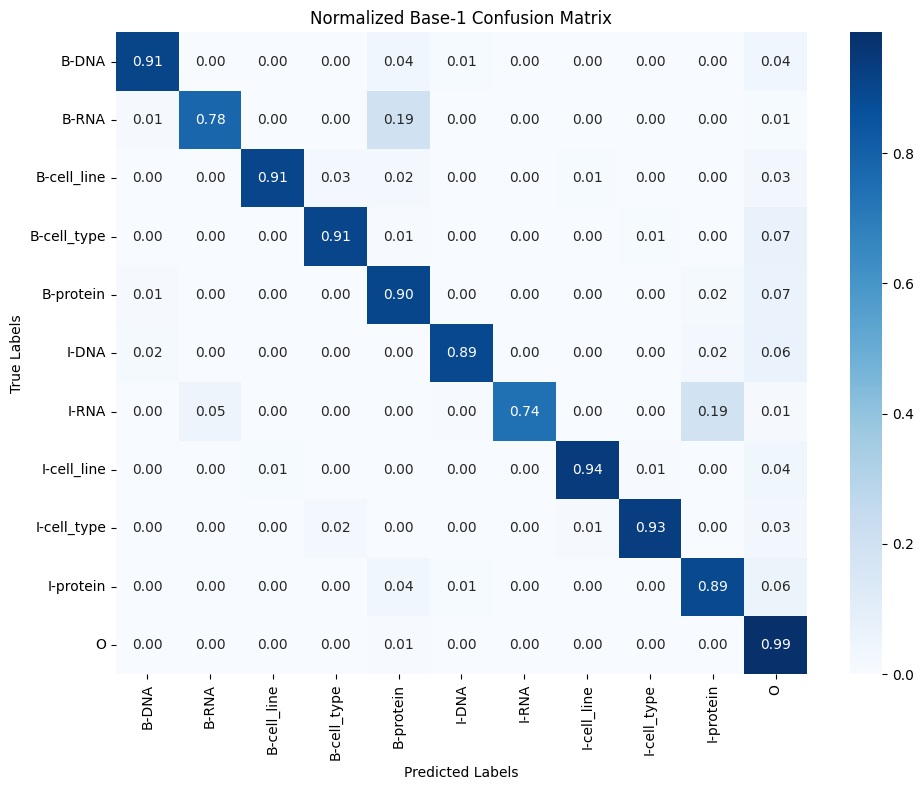

In [ ]:
flat_true = [label for seq in true_labels for label in seq]
flat_pred = [label for seq in pred_labels for label in seq]

labels_unique = sorted(list(set(flat_true + flat_pred)))

cm = confusion_matrix(flat_true, flat_pred, labels=labels_unique, normalize='true')


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_unique,
            yticklabels=labels_unique)
plt.title("Normalized Base-1 Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.savefig("base_1_confusion_matrix_normalized.png", dpi=300)
plt.show()

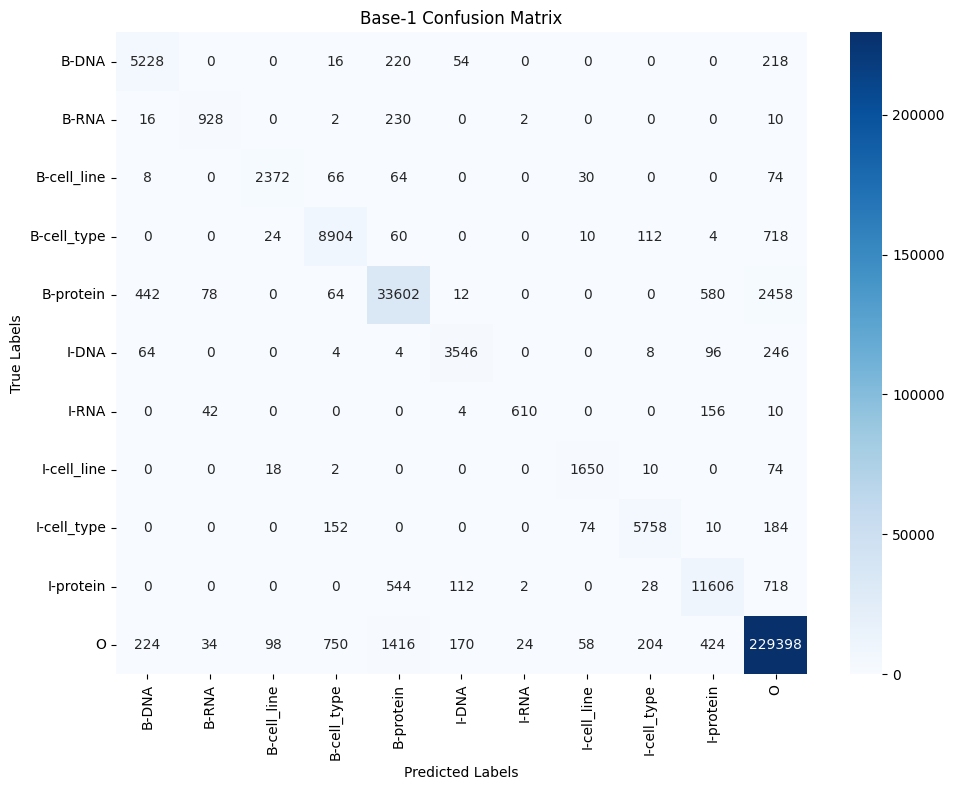

In [ ]:
cm = confusion_matrix(flat_true, flat_pred, labels=labels_unique)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=labels_unique,
            yticklabels=labels_unique)
plt.title("Base-1 Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.savefig("base_1_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
print(classification_report(true_labels, pred_labels))

              precision    recall  f1-score   support

         DNA       0.86      0.90      0.88      5736
         RNA       0.84      0.76      0.80      1188
   cell_line       0.93      0.90      0.92      2614
   cell_type       0.89      0.90      0.89      9832
     protein       0.92      0.89      0.91     37236

   micro avg       0.90      0.89      0.90     56606
   macro avg       0.89      0.87      0.88     56606
weighted avg       0.91      0.89      0.90     56606



# Biobert Weighted Confusion Matrix

In [ ]:
class BIOBERT_Weighted(nn.Module):
    def __init__(self, model_name, num_labels, class_weights=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

        if class_weights is not None:
            self.register_buffer("class_weights", torch.tensor(class_weights, dtype=torch.float))
        else:
            self.class_weights = None

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = self.dropout(outputs.last_hidden_state)
        logits = self.classifier(sequence_output)

        if labels is not None:
            if self.class_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device), ignore_index=-100)
            else:
                loss_fct = nn.CrossEntropyLoss(ignore_index=-100)

            loss = loss_fct(logits.view(-1, logits.shape[-1]), labels.view(-1))
            return {"loss": loss, "logits": logits}
        else:
            return {"logits": logits}

In [ ]:
labels_flat = [label2id[l] for seq in (train_labels + test_labels) for l in seq if l in label2id]
unique_labels = np.unique(labels_flat)
class_weights = compute_class_weight('balanced', classes=unique_labels, y=labels_flat)
tensor_weights = torch.tensor(class_weights, dtype=torch.float)

MODEL_NAME = "dmis-lab/biobert-base-cased-v1.1"
model2 = BIOBERT_Weighted(MODEL_NAME, num_labels=num_labels, class_weights=tensor_weights)

checkpoint = torch.load(BioBERT_Weighted_PATH, map_location="cpu")
model2.load_state_dict(checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

/tmp/ipython-input-2244878403.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("class_weights", torch.tensor(class_weights, dtype=torch.float))


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

<All keys matched successfully>

In [ ]:
model2.eval()
model2.to(device)

true_labels2, pred_labels2 = [], []

with torch.inference_mode():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model2(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs["logits"], dim=2)

        for i in range(len(labels)):
            true_seq, pred_seq = [], []
            for j in range(len(labels[i])):
                if labels[i][j] == -100:
                    continue
                true_seq.append(id2label[labels[i][j].item()])
                pred_seq.append(id2label[predictions[i][j].item()])
            true_labels2.append(true_seq)
            pred_labels2.append(pred_seq)



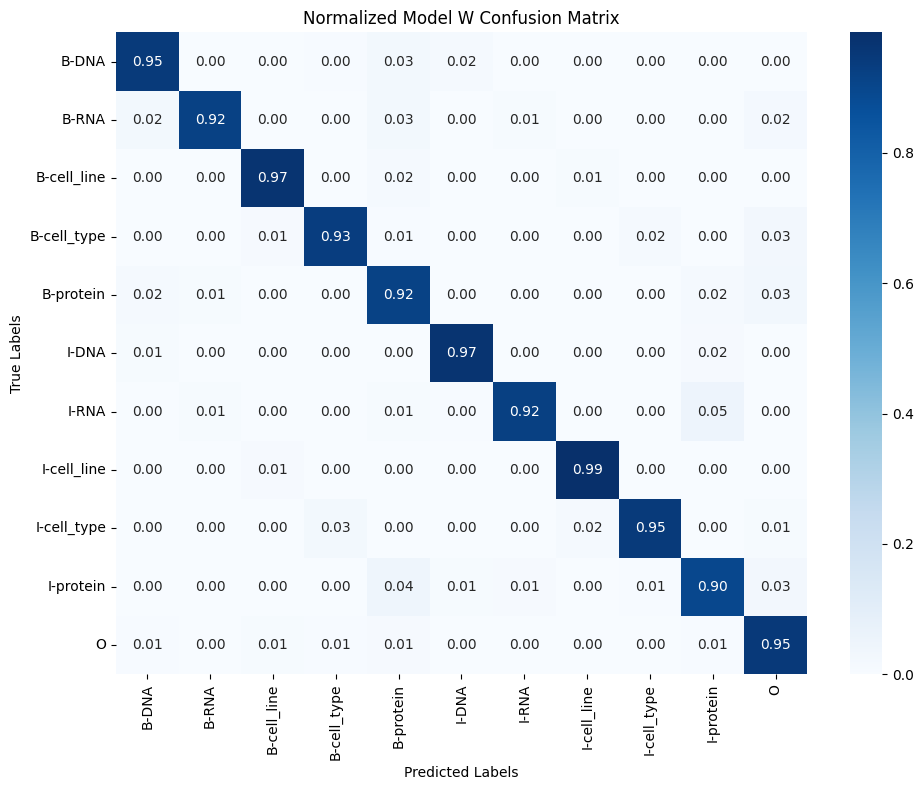

In [ ]:
flat_true2 = [label for seq in true_labels2 for label in seq]
flat_pred2 = [label for seq in pred_labels2 for label in seq]

labels_unique = sorted(list(set(flat_true2 + flat_pred2)))

cm = confusion_matrix(flat_true2, flat_pred2, labels=labels_unique, normalize='true')


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_unique,
            yticklabels=labels_unique)
plt.title("Normalized Model W Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.savefig("W_confusion_matrix_normalized.png", dpi=300)
plt.show()

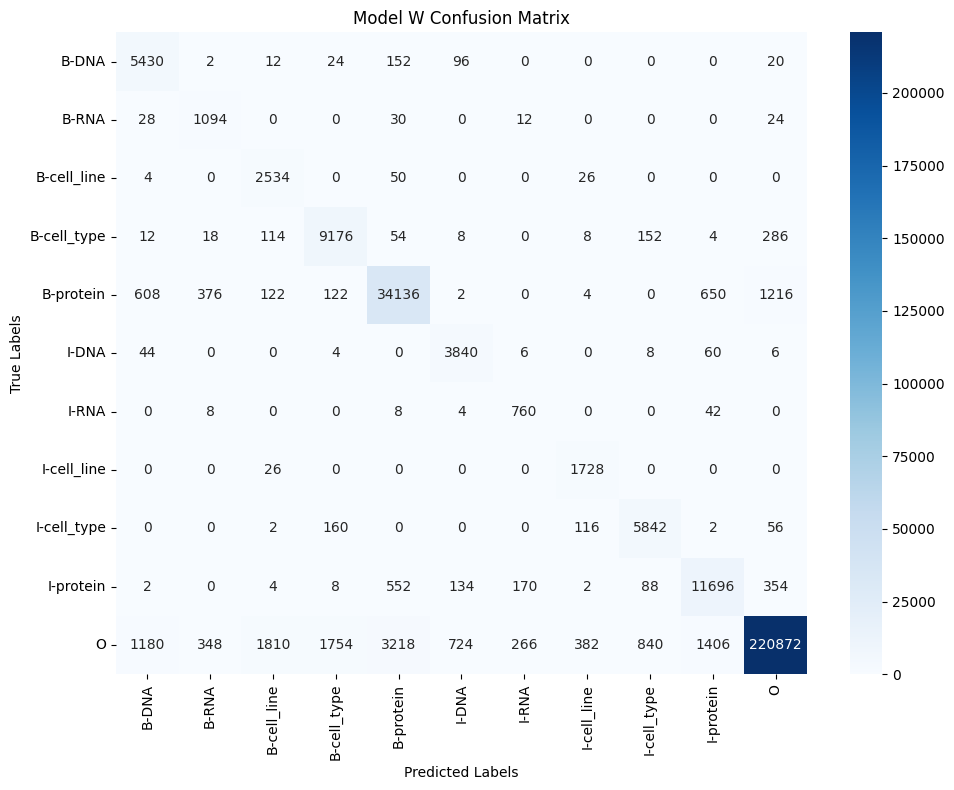

In [ ]:
cm = confusion_matrix(flat_true2, flat_pred2, labels=labels_unique)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=labels_unique,
            yticklabels=labels_unique)
plt.title("Model W Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.savefig("W_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
print(classification_report(true_labels2, pred_labels2))

              precision    recall  f1-score   support

         DNA       0.71      0.93      0.81      5736
         RNA       0.56      0.89      0.68      1188
   cell_line       0.53      0.95      0.68      2614
   cell_type       0.79      0.92      0.85      9832
     protein       0.88      0.90      0.89     37236

   micro avg       0.81      0.91      0.86     56606
   macro avg       0.69      0.92      0.78     56606
weighted avg       0.82      0.91      0.86     56606



In [ ]:
from google.colab import files

files.download("W_confusion_matrix_normalized.png")
files.download("W_confusion_matrix.png")
files.download("base_1_confusion_matrix_normalized.png")
files.download("base_1_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>